# Phase 3 - Notebook 10: BN Structure and CPTs

This notebook documents the Bayesian Network design for Agastya Phase 3 and compares **seed CPTs** against **post-EM CPTs** trained from `data/processed/train.csv`.

## Goals
- Verify BN structure and seed validity
- Train with EM using reproducible data flow
- Compare seed vs trained CPTs quantitatively
- Visualize the final network DAG

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import networkx as nx
import pandas as pd
from matplotlib import pyplot as plt
from pgmpy.models import BayesianNetwork

# Ensure project root is importable when notebook runs from notebooks/Phase_3.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "Phase_3":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase3.bayesian.bootstrap import build_seed_model
from src.phase3.bayesian.em_trainer import train_bn_from_phase2_processed
from src.phase3.bayesian.network import EDGES

In [3]:
def cpd_to_frame(model: BayesianNetwork, variable: str) -> pd.DataFrame:
    cpd = model.get_cpds(variable)
    values = cpd.get_values()
    state_names = cpd.state_names

    if cpd.variables[1:]:
        parent_states = [state_names[parent] for parent in cpd.variables[1:]]
        columns = pd.MultiIndex.from_product(parent_states, names=cpd.variables[1:])
    else:
        columns = pd.Index(["prior"], name="evidence")

    df = pd.DataFrame(values, index=state_names[variable], columns=columns)
    df.index.name = variable
    return df

In [4]:
seed_model = build_seed_model()
assert seed_model.check_model(), "Seed model should be valid"

train_csv = PROJECT_ROOT / "data" / "processed" / "train.csv"
out_model = PROJECT_ROOT / "results" / "phase3" / "bayesian_network.pkl"

trained_model, bn_train_df = train_bn_from_phase2_processed(
    train_csv_path=str(train_csv),
    output_model_path=str(out_model),
    n_iter=30,
)
assert trained_model.check_model(), "Trained model should be valid"

print(f"Training rows (contracts): {len(bn_train_df)}")
print(f"Saved model: {out_model}")

  0%|          | 0/30 [00:00<?, ?it/s]


Training rows (contracts): 408
Saved model: /Users/subhammahapatra/Downloads/agastya/results/phase3/bayesian_network.pkl


In [5]:
variables = [
    "Has_Payment_Clause",
    "Has_Termination_Clause",
    "Has_Liability_Clause",
    "Has_Confidentiality_Clause",
    "Has_Dispute_Resolution_Clause",
    "Payment_Or_Termination_Risky",
    "Liability_Or_Confidentiality_Risky",
    "Cross_Clause_Conflict",
    "Contract_Risk_Level",
]

records = []
for var in variables:
    seed_vals = seed_model.get_cpds(var).get_values().flatten()
    trained_vals = trained_model.get_cpds(var).get_values().flatten()
    for idx, (seed_v, trained_v) in enumerate(zip(seed_vals, trained_vals)):
        records.append(
            {
                "variable": var,
                "entry": idx,
                "seed": float(seed_v),
                "trained": float(trained_v),
                "delta": float(trained_v - seed_v),
            }
        )

comparison_df = pd.DataFrame(records)
comparison_df.head(20)

,variable,entry,seed,trained,delta
0,Has_Payment_Clause,0,0.60,0.460784,-0.139216
1,Has_Payment_Clause,1,0.40,0.539216,0.139216
2,Has_Termination_Clause,0,0.50,0.321078,-0.178922
3,Has_Termination_Clause,1,0.50,0.678922,0.178922
4,Has_Liability_Clause,0,0.55,0.350490,-0.199510
5,Has_Liability_Clause,1,0.45,0.649510,0.199510
6,Has_Confidentiality_Clause,0,0.45,0.443627,-0.006373
7,Has_Confidentiality_Clause,1,0.55,0.556373,0.006373
8,Has_Dispute_Resolution_Clause,0,0.50,0.120098,-0.379902
9,Has_Dispute_Resolution_Clause,1,0.50,0.879902,0.379902


In [6]:
summary = (
    comparison_df.groupby("variable", as_index=False)["delta"]
    .agg(max_abs_delta=lambda s: float(s.abs().max()), mean_abs_delta=lambda s: float(s.abs().mean()))
    .sort_values("max_abs_delta", ascending=False)
)
summary

,variable,max_abs_delta,mean_abs_delta
1,Cross_Clause_Conflict,0.800000,0.392727
0,Contract_Risk_Level,0.744224,0.431408
7,Liability_Or_Confidentiality_Risky,0.650000,0.412500
8,Payment_Or_Termination_Risky,0.600000,0.387500
3,Has_Dispute_Resolution_Clause,0.379902,0.379902
4,Has_Liability_Clause,0.199510,0.199510
6,Has_Termination_Clause,0.178922,0.178922
5,Has_Payment_Clause,0.139216,0.139216
2,Has_Confidentiality_Clause,0.006373,0.006373


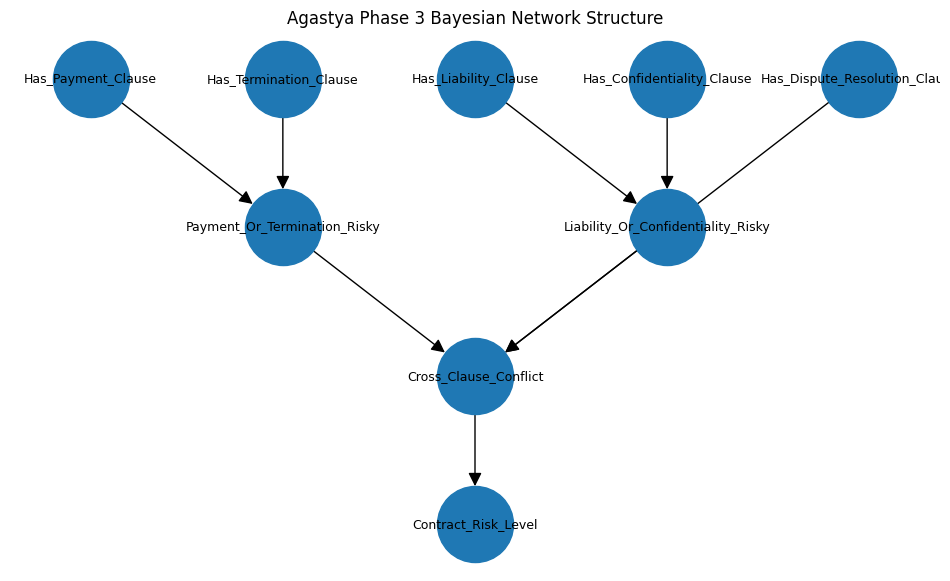

In [7]:
g = nx.DiGraph()
g.add_edges_from(EDGES)

layer_pos = {
    "Has_Payment_Clause": (0, 3),
    "Has_Termination_Clause": (1, 3),
    "Has_Liability_Clause": (2, 3),
    "Has_Confidentiality_Clause": (3, 3),
    "Has_Dispute_Resolution_Clause": (4, 3),
    "Payment_Or_Termination_Risky": (1, 2),
    "Liability_Or_Confidentiality_Risky": (3, 2),
    "Cross_Clause_Conflict": (2, 1),
    "Contract_Risk_Level": (2, 0),
}

plt.figure(figsize=(12, 7))
nx.draw_networkx(
    g,
    pos=layer_pos,
    with_labels=True,
    node_size=3000,
    font_size=9,
    arrowsize=20,
)
plt.title("Agastya Phase 3 Bayesian Network Structure")
plt.axis("off")
plt.show()

In [8]:
reports_dir = PROJECT_ROOT / "reports" / "phase3"
reports_dir.mkdir(parents=True, exist_ok=True)

comparison_path = reports_dir / "cpt_comparison.csv"
summary_path = reports_dir / "cpt_delta_summary.csv"
comparison_df.to_csv(comparison_path, index=False)
summary.to_csv(summary_path, index=False)

print("Saved:")
print(f"- {comparison_path}")
print(f"- {summary_path}")

Saved:
- /Users/subhammahapatra/Downloads/agastya/reports/phase3/cpt_comparison.csv
- /Users/subhammahapatra/Downloads/agastya/reports/phase3/cpt_delta_summary.csv
